## Synthetic Fields Tutorial

In this tutorial, we will go through generating synthetic fields using **kea**.

First import **kea** and other relevant packages like **numpy** for additional array calculations and **matplotlib** for plotting the data.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

Next, we will import the `simulator.make_field` function.

In [2]:
from kea.simulator import make_field

First, we will generate a 2D field:

We will need to tell `make_field()` what the power spectrum should look like (i.e., describe the correlations). Therefore, we provide `spectrum_kwargs` and `spectrum_function` that describe the parameters and the power-spectrum, respectively. The model we will use is simply a power spectrum with a pure powerlaw and is thus described by a single parameter (the powerlaw index: `powerlaw`) which we will set to $-8/3$. This results in a field with a power spectrum that scales as: $k^{-8/3}$.

Have a play around with changing the `powerlaw` parameter. See that its value corresponds to changing the "roughness" of the field.

/home/mark.bishop/Documents/Kea/kea/utils/functions.py:50: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw)


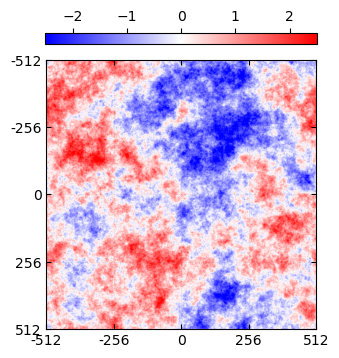

In [3]:
# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3.},
                   spectrum_function='pure_powerlaw',
                   seed=1, normalize_output=True)

## Plot the field
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(field, cmap='bwr', vmin=-2.5, vmax=2.5)
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')


This field looks "random" with enough correlation. However, sometimes more bells and whistles are required to accurately represent astrophysical phenomena. Particularly, it is often the case that the pure powerlaw region is only valid for a subset of the available wavenumbers. Thus, we can instead use a different spectrum function such as: `powerlaw_with_exponentials`. This function requires 3 parameters: `powerlaw`, `break_1`, and `break_2` which describe the behaviour of a large-scale region, intermediate (powerlaw) region, and small-scale region.

Have a play around with changing the parameters; see that `break_1` represents the size of the largest structures in the image. If `break_2` is small enough, then the structure becomes "smooth" and detail is lost.

/home/mark.bishop/Documents/Kea/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark.bishop/Documents/Kea/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in divide
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark.bishop/Documents/Kea/kea/utils/functions.py:126: RuntimeWarning: invalid value encountered in multiply
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)


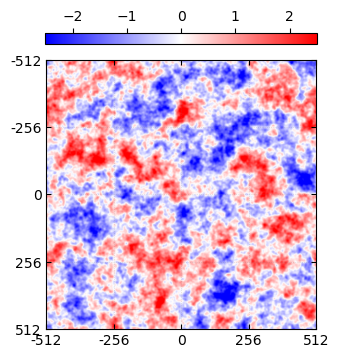

In [4]:
# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'break_1': 2., 'break_2': 64.},
                   spectrum_function='powerlaw_with_exponentials',
                   seed=1, normalize_output=True)

## Plot the field
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(field, cmap='bwr', vmin=-2.5, vmax=2.5)
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')


Next, we will explore _multifractal_ fields. The previous fields had a lot of "visual similarity", they appear to be "uniform" with no spikeyness, singularities, or regions of increased/decreased intensity. _Multifractal_ fields use multiplicative noise to generate more visually (and statistically) distinct structures.

Now, import the `make_multifractal_field()` function.

In [5]:
from kea.simulator import make_multifractal_field

Generating the multifractal field requires additional parameters; there are parameters the control the noise (`gauss_spectrum_kwargs` and `gauss_spectrum_function`) and parameters the control the spectrum of the final field (`spectrum_kwargs` and `spectrum_function`) along with an additional scaling parameter `scaling`. Typically, the resulting field has behaviour the strongly depends on `powerlaw` (of `spectrum_kwargs`) and `scaling`.

Have a play around with the parameters and see what happens.

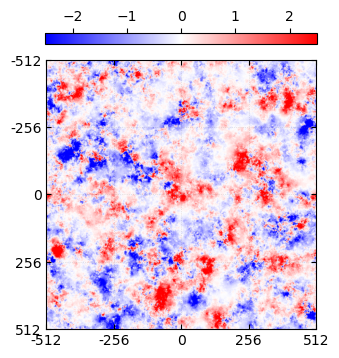

In [6]:
# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_multifractal_field(grid_dims,
                                gauss_spectrum_kwargs={'powerlaw': -(float(D) + 1.), 'cutoff_scale': 5.},
                                gauss_spectrum_function='cutoff_powerlaw',
                                scaling = 0.5,
                                spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                                spectrum_function='cutoff_powerlaw',
                                seeds=(1,2,3), normalize_output=True)

## Plot the field
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(field, cmap='bwr', vmin=-2.5, vmax=2.5)
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')


You now know the basics of generating synthetic fields using **kea**. So far, we have just been examining 2D fields, but it is possible to generate fields of arbitrary dimension. Additionally, if you so desire, you can also provide your own spectrum function as a _Callable_ into `spectrum_function`.

In the next chapter, we will investigate the statistics of these synthetic fields.